In [1]:
import torch
import itertools
from PIL import Image
from torchvision.models import vision_transformer
import matplotlib.pyplot as plt

from zennit.image import imgify
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from lxt.efficient import monkey_patch, monkey_patch_zennit

monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

/Users/erogullari/miniconda3/envs/lxt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched GELU
Patched LayerNorm
Patched MultiheadAttention


/Users/erogullari/miniconda3/envs/lxt/lib/python3.11/site-packages/lxt/efficient/zennit_patches.py:22: UserWarning: 'zennit' library is not available. Please install it to use for vision transformers.
  warn("'zennit' library is not available. Please install it to use for vision transformers.")


NameError: name 'BasicHook' is not defined

In [2]:
def get_vit_imagenet(device="cpu"):
    """
    Load a pre-trained Vision Transformer (ViT) model with ImageNet weights.

    Parameters:
    device (str): Device to load the model on ('cuda' or 'cpu')

    Returns:
    tuple: (model, weights) - The ViT model and its pre-trained weights
    """
    weights = vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval()
    model.to(device)

    # Deactivate gradients on parameters to save memory
    for param in model.parameters():
        param.requires_grad = False

    return model, weights

# Load the pre-trained ViT model
model, weights = get_vit_imagenet()

In [ ]:
# Load and preprocess the input image
image = Image.open('../media/cat_dog.jpg').convert('RGB')
input_tensor = weights.transforms()(image).unsqueeze(0)

# Store the generated heatmaps
heatmaps = []

# Experiment with different gamma values for Conv2d and Linear layers
# Gamma is a hyperparameter in LRP that controls how much positive vs. negative
# contributions are considered in the explanation
for conv_gamma, lin_gamma in itertools.product([0.1, 0.25, 100], [0, 0.01, 0.05, 0.1, 1]):
    input_tensor.grad = None  # Reset gradients
    print("Gamma Conv2d:", conv_gamma, "Gamma Linear:", lin_gamma)

    # Define rules for the Conv2d and Linear layers using 'zennit'
    # LayerMapComposite maps specific layer types to specific LRP rule implementations
    zennit_comp = LayerMapComposite([
        (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
        (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
    ])

    # Register the composite rules with the model
    zennit_comp.register(model)

    # Forward pass with gradient tracking enabled
    y = model(input_tensor.requires_grad_())

    # Get the top 5 predictions
    _, top5_classes = torch.topk(y, 5, dim=1)
    top5_classes = top5_classes.squeeze(0).tolist()

    # Get the class labels
    labels = weights.meta["categories"]
    top5_labels = [labels[class_idx] for class_idx in top5_classes]

    # Print the top 5 predictions and their labels
    for i, class_idx in enumerate(top5_classes):
        print(f'Top {i+1} predicted class: {class_idx}, label: {top5_labels[i]}')

    # Backward pass for the highest probability class
    # This initiates the LRP computation through the network
    y[0, top5_classes[0]].backward()

    # Remove the registered composite to prevent interference in future iterations
    zennit_comp.remove()

    # Calculate the relevance by computing Input*Gradient
    # This is the final step of LRP to get the pixel-wise explanation
    heatmap = (input_tensor * input_tensor.grad).sum(1)

    # Normalize relevance between [-1, 1] for plotting
    heatmap = heatmap / abs(heatmap).max()

    # Store the normalized heatmap
    heatmaps.append(heatmap[0].detach().cpu().numpy())

Gamma Conv2d: 0.1 Gamma Linear: 0
Top 1 predicted class: 156, label: Blenheim spaniel
Top 2 predicted class: 213, label: Irish setter
Top 3 predicted class: 157, label: papillon
Top 4 predicted class: 187, label: Yorkshire terrier
Top 5 predicted class: 215, label: Brittany spaniel
Gamma Conv2d: 0.1 Gamma Linear: 0.01
Top 1 predicted class: 156, label: Blenheim spaniel
Top 2 predicted class: 213, label: Irish setter
Top 3 predicted class: 157, label: papillon
Top 4 predicted class: 187, label: Yorkshire terrier
Top 5 predicted class: 215, label: Brittany spaniel
Gamma Conv2d: 0.1 Gamma Linear: 0.05
Top 1 predicted class: 156, label: Blenheim spaniel
Top 2 predicted class: 213, label: Irish setter
Top 3 predicted class: 157, label: papillon
Top 4 predicted class: 187, label: Yorkshire terrier
Top 5 predicted class: 215, label: Brittany spaniel
Gamma Conv2d: 0.1 Gamma Linear: 0.1
Top 1 predicted class: 156, label: Blenheim spaniel
Top 2 predicted class: 213, label: Irish setter
Top 3 pre

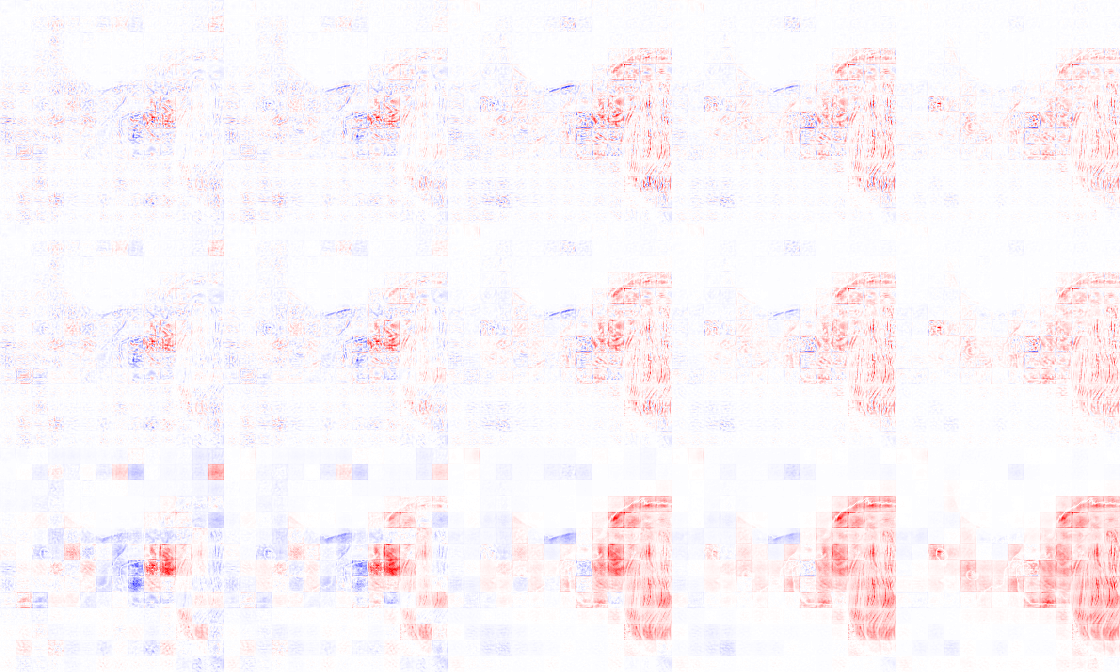

In [7]:
# Visualize all heatmaps in a grid (3×5) and save to a file
# vmin and vmax control the color mapping range
imgify(heatmaps, vmin=-1, vmax=1, grid=(3, 5))